Configuración y Carga de Datos

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from rapidfuzz import process, fuzz
from transformers import pipeline
from tqdm import tqdm

# Configuración visual y barras de progreso
tqdm.pandas()
sns.set_theme(style="whitegrid", palette="muted")

# Cargamos el dataset
archivo = 'songs_with_years_processed.csv'
print(f"Cargando dataset: {archivo}...")
df = pd.read_csv(archivo)

# Limpieza de seguridad básica
df = df.dropna(subset=['lyrics', 'word_count'])
df['lyrics'] = df['lyrics'].astype(str)

# Evitamos división por cero en el cálculo de frecuencias
df['word_count'] = df['word_count'].replace(0, 1)

print(f"Total de canciones listas para analizar: {len(df)}")
display(df.head(2))

Cargando dataset: songs_with_years_processed.csv...
Total de canciones listas para analizar: 7933


,lyrics,artist_clean,genre_clean,word_count,song_norm,song,year,emocion_predominante_genero,top3_emociones_predominantes_genero
0,"Hey you little Jesus' bride, why have you smil...",moonspell,Metal,197,let the children cum to me...,Let The Children Cum To Me...,2008,annoyance,"annoyance, approval, sadness"
1,"I am the moment, the soul\nThe moment that end...",moonspell,Metal,219,memento mori,Memento Mori,2020,annoyance,"annoyance, approval, sadness"


Extracción Léxica (Diccionario de Palabras Ofensivas)

In [ ]:

print("1. Extrayendo el vocabulario único del dataset...")

texto_global = " ".join(df['lyrics'].tolist()).lower()
vocabulario_dataset = set(re.findall(r'\b[a-z]+\b', texto_global))

# Machismo / Sexismo
dict_sexist_base = [
    'bitch', 'bitches', 'biatch', 'bish', 'hoe', 'hoes', 'slut', 'sluts', 
    'whore', 'whores', 'skank', 'skanks', 'cunt', 'cunts', 'thot', 'thots', 
    'bimbo', 'bimbos', 'cumslut', 'bitchy', 'bitching', 'skeezer', 'skeezers', 
    'hoodrat', 'hoodrats', 'chickenhead', 'chickenheads', 'hoochie', 'hoochies', 
    'groupie', 'groupies', 'pimp', 'pimps', 'golddigger', 'golddiggers',
    'sket', 'skets', 'slapper', 'slappers', 'minger', 'mingers', 
    'hooker', 'hookers', 'harlot', 'harlots', 'milf', 'milfs', 'floozy', 'floozies'
]

# Racismo / Xenofobia
dict_racist_base = [
    'nigga', 'niggas', 'nigger', 'niggers', 'jigaboo', 'jigaboos', 
    'sambo', 'pickaninny', 'darkie', 'darkies', 'moolie', 'moolies', 
    'tarbaby', 'wigger', 'wigga', 'honky', 'honkies', 'peckerwood', 
    'trailerpark', 'chav', 'chavs', 'spic', 'spics', 'wetback', 'wetbacks', 
    'beaner', 'beaners', 'cholo', 'cholas', 'chink', 'chinks', 'gook', 'gooks', 
    'nip', 'nips', 'coolie', 'coolies', 'kike', 'kikes', 'raghead', 'ragheads', 
    'towelhead', 'towelheads', 'paki', 'pakis', 'wop', 'wops', 'guido', 'guidos', 
    'mick', 'micks'
]

# Homofobia / Transfobia 
dict_homophobic_base = [
    'faggot', 'faggots', 'fag', 'fags', 'fagot', 'fagots', 'faggotry',
    'dyke', 'dykes', 'homo', 'homos', 'sodomite', 'sodomites', 'lesbo', 'lesbos', 
    'sissy', 'sissies', 'nancyboy', 'fudgepacker', 'carpetmuncher', 'pillowbiter',
    'poof', 'poofs', 'poofter', 'poofters', 'battyboy', 'battyboys', 'battybwoy', 
    'battybwoys', 'battyhole', 'chichiman', 'chi-chi', 
    'tranny', 'trannies', 'shemale', 'shemales', 'he-she', 'heshe', 
    'shim', 'shims', 'ladyboy', 'ladyboys', 'genderbender'
]

# Insultos Generales
dict_profanity_base = [
    'fuck', 'fucking', 'fucker', 'fuckers', 'motherfucker', 'motherfuckers', 
    'muthafucka', 'mofo', 'mofos', 'shit', 'shits', 'bullshit', 
    'asshole', 'assholes', 'pussy', 'pussies', 'cocksucker', 'cocksuckers', 
    'bastard', 'bastards', 'goddamn', 'douche', 'douchebag', 'douchebags', 
    'bitchass', 'dumbass', 'jackass', 'dickhead', 'dickheads', 'shithead', 'dipshit', 
    'fuckface', 'fucktard', 'wanker', 'wankers', 'bollocks', 'arsehole', 
    'shite', 'tosser', 'tossers', 'bellend', 'spastic', 'schizo'
]

def expandir_diccionario_estricto(diccionario_base, vocabulario_total):
    diccionario_expandido = set(diccionario_base)
    for palabra_base in diccionario_base:
        # Umbral durísimo para evitar cruces (ej. bitch vs itch)
        umbral = 95 if len(palabra_base) <= 5 else 85
        coincidencias = process.extract(
            palabra_base, vocabulario_total, scorer=fuzz.ratio, score_cutoff=umbral
        )
        for coincidencia, puntuacion, _ in coincidencias:
            if abs(len(palabra_base) - len(coincidencia)) <= 1:
                diccionario_expandido.add(coincidencia)
    return diccionario_expandido

print("2. Expandiendo diccionarios de forma estricta...")
dict_sexist_full = expandir_diccionario_estricto(dict_sexist_base, vocabulario_dataset)
dict_racist_full = expandir_diccionario_estricto(dict_racist_base, vocabulario_dataset)
dict_homophobic_full = expandir_diccionario_estricto(dict_homophobic_base, vocabulario_dataset)
dict_profanity_full = expandir_diccionario_estricto(dict_profanity_base, vocabulario_dataset)

def contar_blindado(texto, diccionario_full):
    palabras = re.findall(r'\b[a-z]+\b', str(texto).lower())
    return sum(1 for p in palabras if p in diccionario_full)

print("3. Contando palabras en las 4 categorías...")
df['count_sexist'] = df['lyrics'].apply(lambda x: contar_blindado(x, dict_sexist_full))
df['count_racist'] = df['lyrics'].apply(lambda x: contar_blindado(x, dict_racist_full))
df['count_homophobic'] = df['lyrics'].apply(lambda x: contar_blindado(x, dict_homophobic_full))
df['count_profanity'] = df['lyrics'].apply(lambda x: contar_blindado(x, dict_profanity_full))

df['freq_sexist_pct'] = (df['count_sexist'] / df['word_count']) * 100
df['freq_racist_pct'] = (df['count_racist'] / df['word_count']) * 100
df['freq_homophobic_pct'] = (df['count_homophobic'] / df['word_count']) * 100
df['freq_profanity_pct'] = (df['count_profanity'] / df['word_count']) * 100

print("¡Fase Léxica de Alta Precisión completada!")

1. Extrayendo el vocabulario único del dataset...
2. Expandiendo diccionarios de forma estricta...
3. Contando palabras en las 4 categorías...
¡Fase Léxica de Alta Precisión completada!


Análisis de Contexto (Transformers)

In [6]:

print("Cargando modelo de IA (unitary/toxic-bert)...")
detector_ia = pipeline("text-classification", model="unitary/toxic-bert", device=-1)

def evaluar_toxicidad_segura(texto):
    texto_str = str(texto)
    if not texto_str.strip(): return 0.0
    
    # Recorte estricto de seguridad para no pasarnos de tokens
    texto_seguro = " ".join(texto_str.split()[:250])
    
    try:
        # Intentamos con top_k para que nos devuelva todas las categorías
        try:
            resultado = detector_ia(texto_seguro, truncation=True, max_length=512, top_k=None)
        except TypeError:
            # Fallback para versiones antiguas de la librería
            resultado = detector_ia(texto_seguro, truncation=True, max_length=512, return_all_scores=True)
            
        # Comprobamos si el resultado es una lista dentro de otra lista, o una lista simple
        lista_resultados = resultado[0] if isinstance(resultado[0], list) else resultado
        
        # Ahora iteramos de forma segura buscando la puntuación de toxicidad
        for cat in lista_resultados:
            if cat.get('label') == 'toxic':
                return cat.get('score', 0.0) * 100
                
        # Si por algún motivo el modelo no devuelve la etiqueta 'toxic', asumimos 0
        return 0.0
        
    except Exception as e:
        print(f"Error procesando '{texto_seguro[:20]}...': {e}")
        return 0.0

print("Evaluando canciones. ¡Ahora sí, libre de errores!...")
df['ia_toxic_score'] = df['lyrics'].progress_apply(evaluar_toxicidad_segura)

print("¡Fase de IA completada con éxito!")

Cargando modelo de IA (unitary/toxic-bert)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: unitary/toxic-bert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Evaluando canciones. ¡Ahora sí, libre de errores!...


100%|██████████| 7933/7933 [14:23:44<00:00,  6.53s/it]       

¡Fase de IA completada con éxito!


Análisis Exploratorio y Gráficos

Generando visualizaciones para el proyecto...


C:\Users\pablo\AppData\Local\Temp\ipykernel_14928\177256487.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artistas.values, y=top_artistas.index, palette="Reds_r")


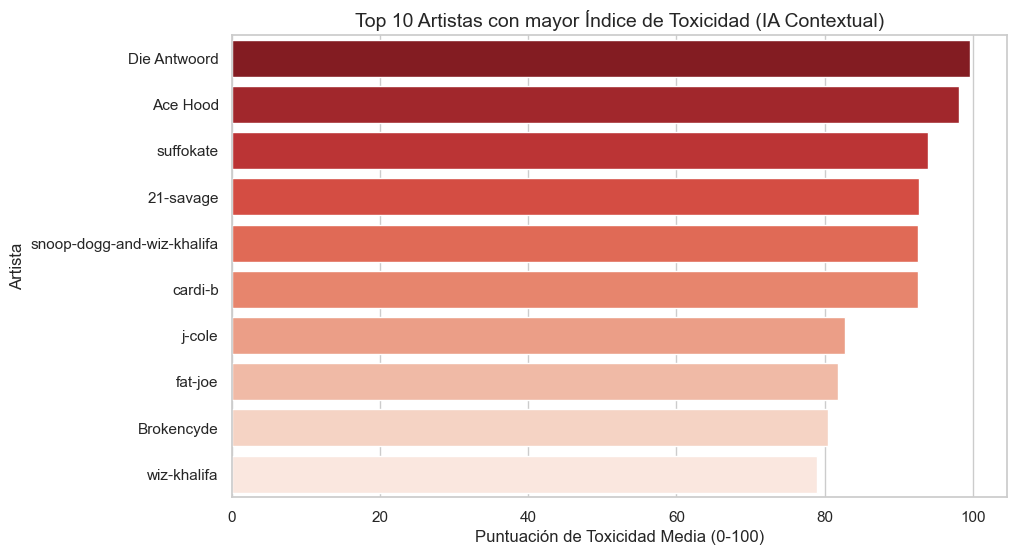

<Figure size 1200x600 with 0 Axes>

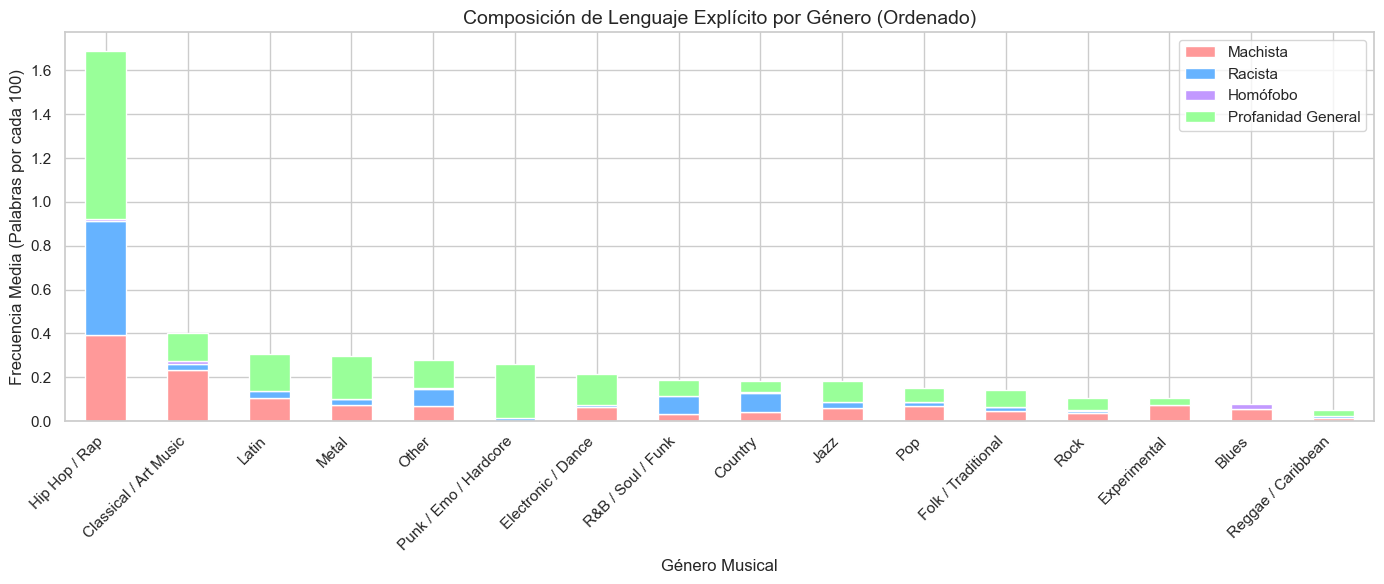

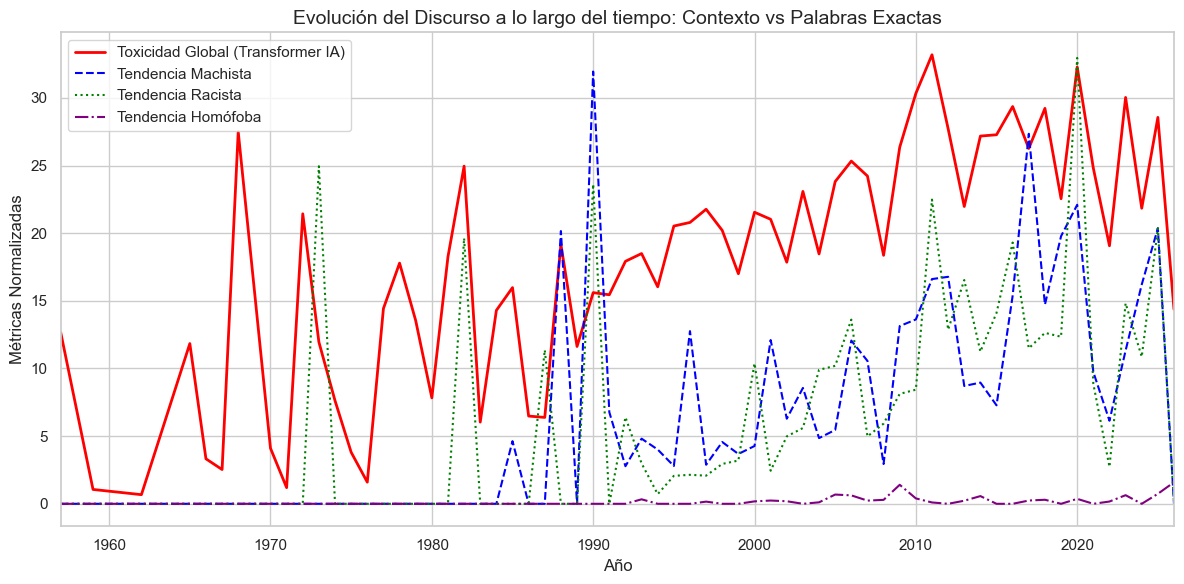

Generando el ranking de las palabras exactas más utilizadas...


C:\Users\pablo\AppData\Local\Temp\ipykernel_14928\177256487.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_sexist, x='Apariciones', y='Palabra', palette="flare")


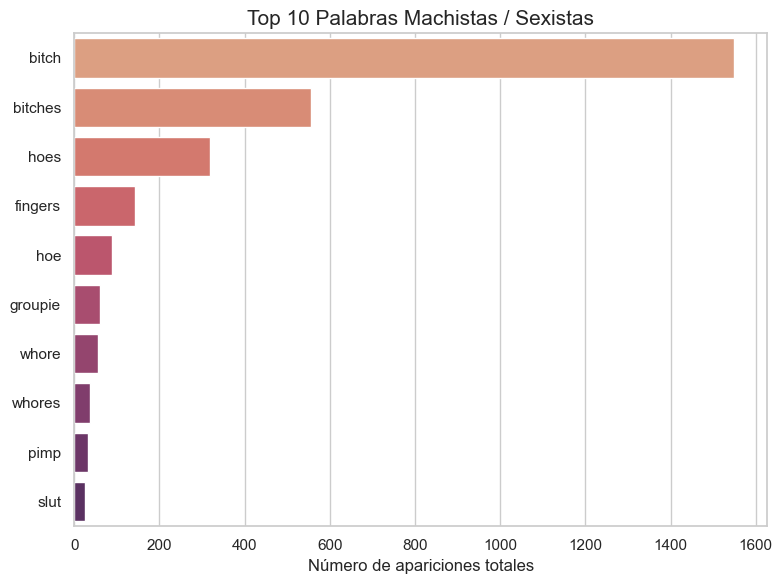

C:\Users\pablo\AppData\Local\Temp\ipykernel_14928\177256487.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_racist, x='Apariciones', y='Palabra', palette="crest")


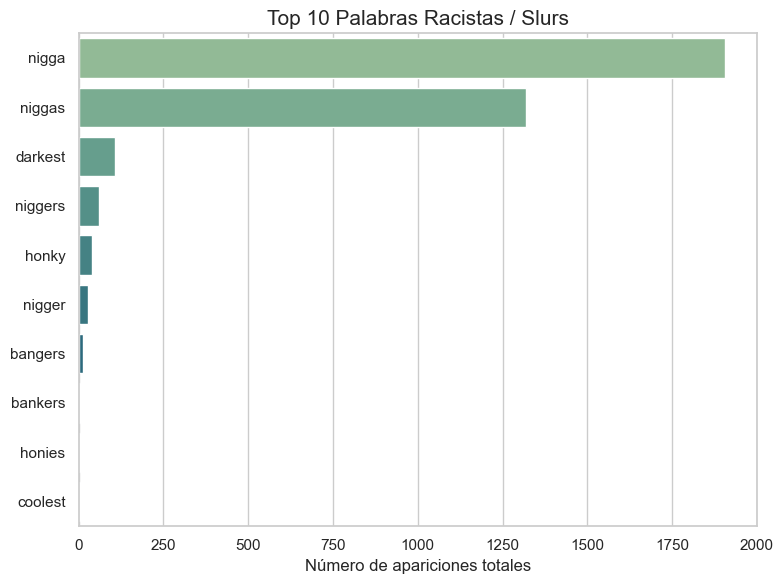

C:\Users\pablo\AppData\Local\Temp\ipykernel_14928\177256487.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_homo, x='Apariciones', y='Palabra', palette="Purples_r")


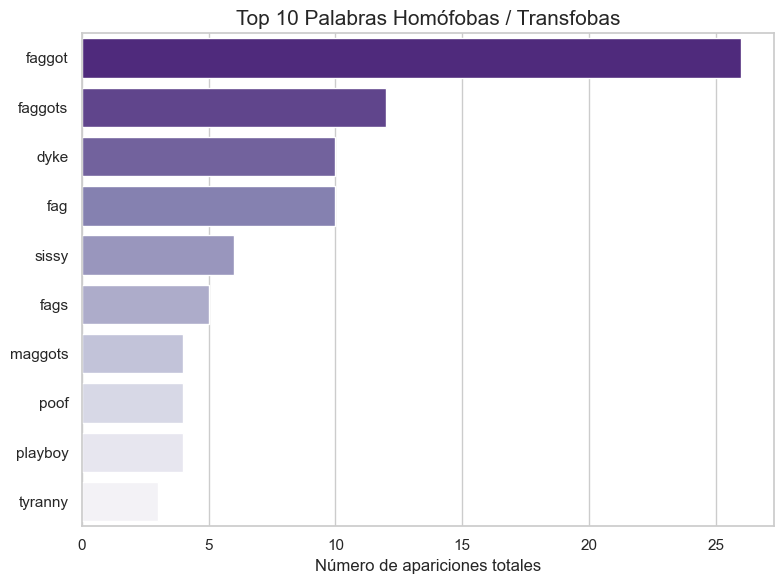

C:\Users\pablo\AppData\Local\Temp\ipykernel_14928\177256487.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_profanity, x='Apariciones', y='Palabra', palette="magma")


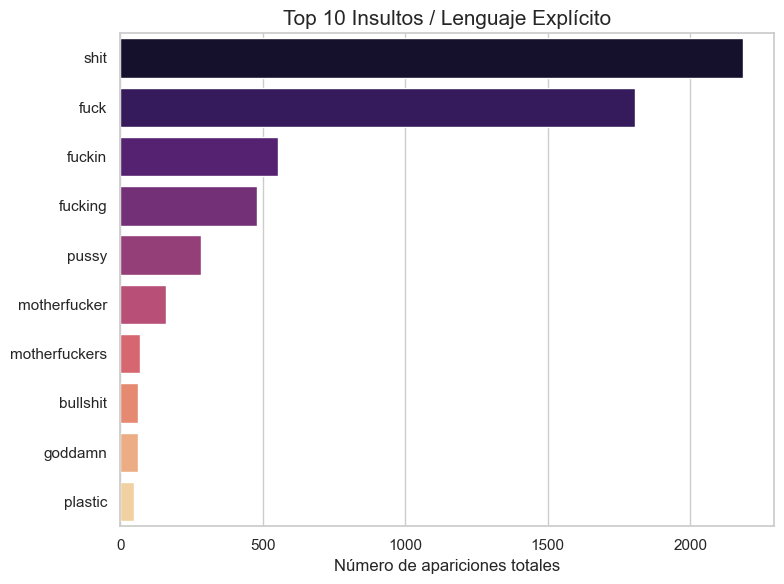

¡Análisis terminado! Dataset con métricas guardado como 'songs_analyzed_final.csv'


In [7]:

print("Generando visualizaciones para el proyecto...")

# GRÁFICO 1: TOP 10 ARTISTAS MÁS TÓXICOS
plt.figure(figsize=(10, 6))
canciones_por_artista = df['artist_clean'].value_counts()
artistas_validos = canciones_por_artista[canciones_por_artista >= 5].index
df_artistas = df[df['artist_clean'].isin(artistas_validos)]

top_artistas = df_artistas.groupby('artist_clean')['ia_toxic_score'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_artistas.values, y=top_artistas.index, palette="Reds_r")
plt.title('Top 10 Artistas con mayor Índice de Toxicidad (IA Contextual)', fontsize=14)
plt.xlabel('Puntuación de Toxicidad Media (0-100)')
plt.ylabel('Artista')
plt.show()

# GRÁFICO 2: COMPOSICIÓN DE ODIO POR GÉNERO
plt.figure(figsize=(12, 6))
columnas_freq = ['freq_sexist_pct', 'freq_racist_pct', 'freq_homophobic_pct', 'freq_profanity_pct']
generos_grouped = df.groupby('genre_clean')[columnas_freq].mean()

generos_grouped['Total_Toxicidad'] = generos_grouped.sum(axis=1)
generos_grouped = generos_grouped.sort_values(by='Total_Toxicidad', ascending=False)
generos_grouped = generos_grouped.drop(columns=['Total_Toxicidad'])

colores = ['#ff9999', '#66b3ff', '#c299ff', '#99ff99']
generos_grouped.plot(kind='bar', stacked=True, figsize=(14,6), color=colores)
plt.title('Composición de Lenguaje Explícito por Género (Ordenado)', fontsize=14)
plt.xlabel('Género Musical')
plt.ylabel('Frecuencia Media (Palabras por cada 100)')
plt.legend(['Machista', 'Racista', 'Homófobo', 'Profanidad General'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# GRÁFICO 3: EVOLUCIÓN TEMPORAL COMPARATIVA
plt.figure(figsize=(12, 6))
temporal = df.groupby('year').agg(
    IA_Contexto=('ia_toxic_score', 'mean'),
    Exact_Sexist=('freq_sexist_pct', 'mean'),
    Exact_Racist=('freq_racist_pct', 'mean'),
    Exact_Homophobic=('freq_homophobic_pct', 'mean')
).reset_index()

factor_escala = temporal['IA_Contexto'].max() / (temporal['Exact_Sexist'].max() + 0.01)

sns.lineplot(data=temporal, x='year', y='IA_Contexto', label='Toxicidad Global (Transformer IA)', color='red', linewidth=2)
sns.lineplot(x=temporal['year'], y=temporal['Exact_Sexist'] * factor_escala, label='Tendencia Machista', color='blue', linestyle='dashed')
sns.lineplot(x=temporal['year'], y=temporal['Exact_Racist'] * factor_escala, label='Tendencia Racista', color='green', linestyle='dotted')
sns.lineplot(x=temporal['year'], y=temporal['Exact_Homophobic'] * factor_escala, label='Tendencia Homófoba', color='purple', linestyle='dashdot')

plt.title('Evolución del Discurso a lo largo del tiempo: Contexto vs Palabras Exactas', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Métricas Normalizadas')
plt.xlim(df['year'].min(), df['year'].max())
plt.legend()
plt.tight_layout()
plt.show()


# EL RANKING DE LAS PALABRAS OFENSIVAS

from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

print("Generando el ranking de las palabras exactas más utilizadas...")

# Extracción y conteo global
todas_las_letras = " ".join(df['lyrics'].tolist()).lower()
todas_las_palabras = re.findall(r'\b[a-z]+\b', todas_las_letras)
conteo_global = Counter(todas_las_palabras)

# Filtrado por nuestros diccionarios purgados
conteo_sexist = {w: c for w, c in conteo_global.items() if w in dict_sexist_full}
conteo_racist = {w: c for w, c in conteo_global.items() if w in dict_racist_full}
conteo_homophobic = {w: c for w, c in conteo_global.items() if w in dict_homophobic_full}
conteo_profanity = {w: c for w, c in conteo_global.items() if w in dict_profanity_full}

# Creación de los DataFrames con los Top 10
df_top_sexist = pd.DataFrame(Counter(conteo_sexist).most_common(10), columns=['Palabra', 'Apariciones'])
df_top_racist = pd.DataFrame(Counter(conteo_racist).most_common(10), columns=['Palabra', 'Apariciones'])
df_top_homo = pd.DataFrame(Counter(conteo_homophobic).most_common(10), columns=['Palabra', 'Apariciones'])
df_top_profanity = pd.DataFrame(Counter(conteo_profanity).most_common(10), columns=['Palabra', 'Apariciones'])

# VISUALIZACIÓN

# GRÁFICO 4: MACHISMO
plt.figure(figsize=(8, 6))
sns.barplot(data=df_top_sexist, x='Apariciones', y='Palabra', palette="flare")
plt.title('Top 10 Palabras Machistas / Sexistas', fontsize=15)
plt.xlabel('Número de apariciones totales', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

# GRÁFICO 5: RACISMO
plt.figure(figsize=(8, 6))
sns.barplot(data=df_top_racist, x='Apariciones', y='Palabra', palette="crest")
plt.title('Top 10 Palabras Racistas / Slurs', fontsize=15)
plt.xlabel('Número de apariciones totales', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

# GRÁFICO 6: HOMOFOBIA
plt.figure(figsize=(8, 6))
sns.barplot(data=df_top_homo, x='Apariciones', y='Palabra', palette="Purples_r")
plt.title('Top 10 Palabras Homófobas / Transfobas', fontsize=15)
plt.xlabel('Número de apariciones totales', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

# GRÁFICO 7: PROFANIDAD GENERAL
plt.figure(figsize=(8, 6))
sns.barplot(data=df_top_profanity, x='Apariciones', y='Palabra', palette="magma")
plt.title('Top 10 Insultos / Lenguaje Explícito', fontsize=15)
plt.xlabel('Número de apariciones totales', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

# --- GUARDAR EL DATASET FINAL ENRIQUECIDO ---
# Guarda un nuevo CSV con todas las columnas calculadas para no tener que reprocesar en el futuro
df.to_csv('songs_analyzed_final.csv', index=False)
print("¡Análisis terminado! Dataset con métricas guardado como 'songs_analyzed_final.csv'")

Estudio de Lenguaje Religioso

Iniciando análisis de Lenguaje Religioso...
Diccionario religioso expandido a 82 palabras.
Métricas religiosas calculadas.



C:\Users\pablo\AppData\Local\Temp\ipykernel_14928\2172857205.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_religion, x='Apariciones', y='Palabra', ax=ax1, palette="YlOrBr")
C:\Users\pablo\AppData\Local\Temp\ipykernel_14928\2172857205.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=generos_religiosos.values, y=generos_religiosos.index, ax=ax2, palette="YlOrBr_r")


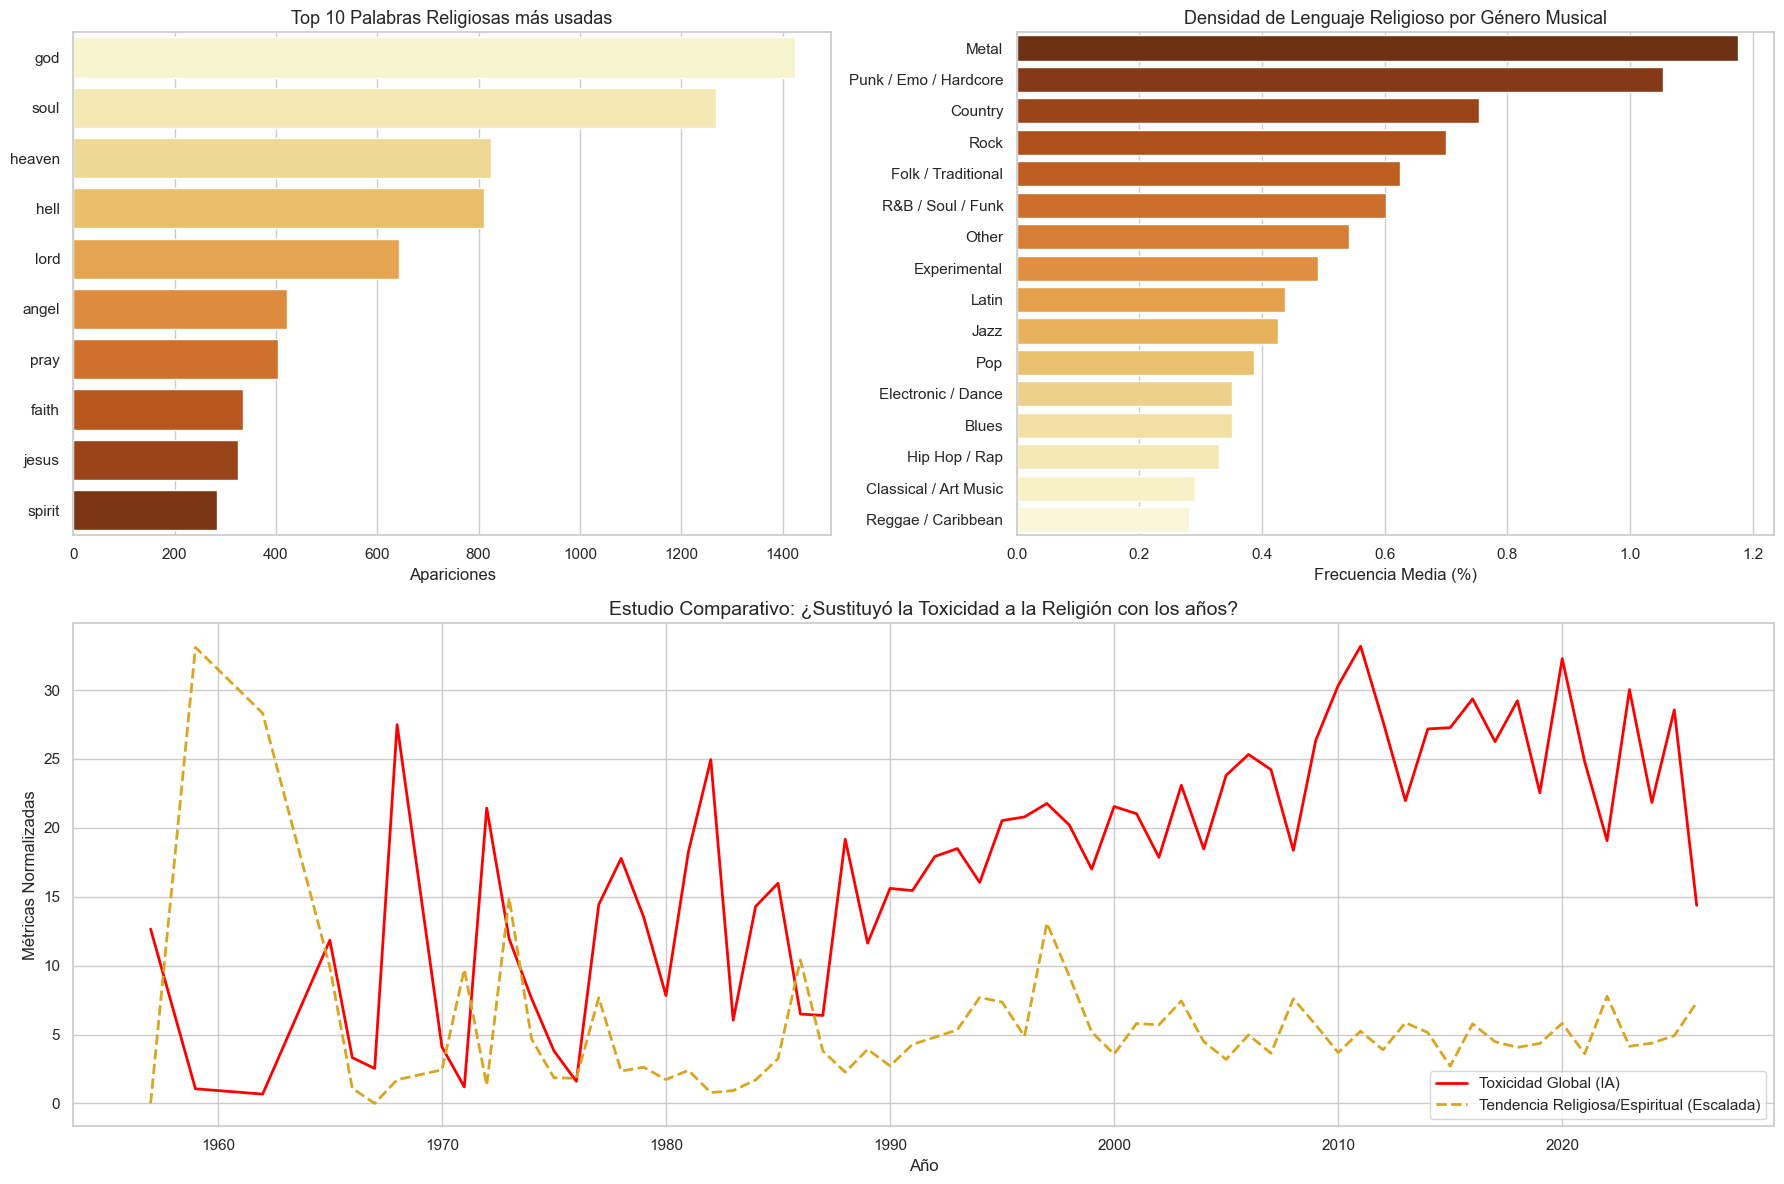

In [ ]:

print("Iniciando análisis de Lenguaje Religioso...")

# Diccionario Base (Cristianismo, Islam, Judaísmo, Oriental y Espiritualidad General)
dict_religion_base = [
    'god', 'gods', 'jesus', 'christ', 'lord', 'holy', 'heaven', 'hell', 
    'angel', 'angels', 'demon', 'demons', 'devil', 'devils', 'satan', 'sin', 'sins', 
    'pray', 'praying', 'prayer', 'prayers', 'church', 'churches', 'amen', 'hallelujah',
    'faith', 'divine', 'sacred', 'soul', 'souls', 'spirit', 'spirits', 'savior', 
    'pastor', 'pastors', 'priest', 'priests', 'saint', 'saints', 'bible', 'bibles', 
    'allah', 'quran', 'mosque', 'prophet', 'prophets', 'yahweh', 'torah', 'rabbi', 
    'synagogue', 'karma', 'buddha', 'temple', 'temples', 'nirvana', 'gospel'
]

# Expandimos el diccionario
dict_religion_full = expandir_diccionario_estricto(dict_religion_base, vocabulario_dataset)

# Aplicamos el conteo y calculamos la densidad sin afectar a las otras columnas
df['count_religious'] = df['lyrics'].apply(lambda x: contar_blindado(x, dict_religion_full))
df['freq_religious_pct'] = (df['count_religious'] / df['word_count']) * 100

print(f"Diccionario religioso expandido a {len(dict_religion_full)} palabras.")
print("Métricas religiosas calculadas.\n")

# VISUALIZACIONES DEL LENGUAJE RELIGIOSO
from collections import Counter

# Preparamos Top Palabras Religiosas
conteo_religion = {w: c for w, c in conteo_global.items() if w in dict_religion_full}
df_top_religion = pd.DataFrame(Counter(conteo_religion).most_common(10), columns=['Palabra', 'Apariciones'])

# Creamos la figura con 3 gráficas
fig = plt.figure(figsize=(18, 12))

# Gráfico 1: Top 10 Palabras Religiosas
ax1 = plt.subplot(2, 2, 1)
sns.barplot(data=df_top_religion, x='Apariciones', y='Palabra', ax=ax1, palette="YlOrBr")
ax1.set_title('Top 10 Palabras Religiosas más usadas', fontsize=13)
ax1.set_ylabel('')

# Gráfico 2: Lenguaje Religioso por Género
ax2 = plt.subplot(2, 2, 2)
generos_religiosos = df.groupby('genre_clean')['freq_religious_pct'].mean().sort_values(ascending=False)
sns.barplot(x=generos_religiosos.values, y=generos_religiosos.index, ax=ax2, palette="YlOrBr_r")
ax2.set_title('Densidad de Lenguaje Religioso por Género Musical', fontsize=13)
ax2.set_xlabel('Frecuencia Media (%)')
ax2.set_ylabel('')

# Gráfico 3: Religión vs Toxicidad a lo largo del tiempo
ax3 = plt.subplot(2, 1, 2)
temporal_religion = df.groupby('year').agg(
    IA_Contexto=('ia_toxic_score', 'mean'),
    Religion_Freq=('freq_religious_pct', 'mean')
).reset_index()

# Escalamos para comparar las tendencias visualmente
escala_rel = temporal_religion['IA_Contexto'].max() / (temporal_religion['Religion_Freq'].max() + 0.01)

sns.lineplot(data=temporal_religion, x='year', y='IA_Contexto', ax=ax3, label='Toxicidad Global (IA)', color='red', linewidth=2)
sns.lineplot(x=temporal_religion['year'], y=temporal_religion['Religion_Freq'] * escala_rel, ax=ax3, label='Tendencia Religiosa/Espiritual (Escalada)', color='goldenrod', linestyle='dashed', linewidth=2)

ax3.set_title('Estudio Comparativo: ¿Sustituyó la Toxicidad a la Religión con los años?', fontsize=14)
ax3.set_xlabel('Año')
ax3.set_ylabel('Métricas Normalizadas')
ax3.legend()

plt.tight_layout()
plt.show()